# Data Cleaning

Data cleaning involves identifying and removing any missing, duplicate or irrelevant data.

Raw data (log file, transactions, audio /video recordings, etc) is often noisy, incomplete and inconsistent which can negatively impact the accuracy of the model.
The goal of data cleaning is to ensure that the data is accurate, consistent and free of errors.
Clean datasets are also important in EDA (Exploratory Data Analysis), which enhances the interpretability of data so that the right actions can be taken based on insights.

# How to Perform Data Cleaning

Data cleaning involves identifying issues like missing values, duplicates, and outliers, followed by applying appropriate techniques to fix them. The following steps are essential to perform data cleaning:

- Remove Unwanted Observations: Eliminate duplicates, irrelevant entries or redundant data that add noise.

- Fix Structural Errors: Standardize data formats and variable types for consistency.

- Manage Outliers: Detect and handle extreme values that can skew results, either by removal or transformation.

- Handle Missing Data: Address gaps using imputation, deletion or advanced techniques to maintain accuracy and integrity.

## Implementation for Data Cleaning

Let's understand each step for Database Cleaning using titanic dataset.

### Step 1: Import Libraries and Load Dataset

We will import all the necessary libraries i.e pandas and numpy.

In [112]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Datasets/Titanic-Dataset.csv')     # .. means: "Go one folder up (to the parent directory)"

### IMPORTANT NOTE
| Path          | Meaning                            |
| ------------- | ---------------------------------- |
| `.`           | Current folder (`Notes`)           |
| `..`          | One folder up (`Machine Learning`) |
| `../Datasets` | Go up, then into `Datasets`        |
| `../../`      | Go up **two levels**               |

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [114]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 2: Check for Duplicate Rows

- df.duplicated(): Returns a boolean Series indicating duplicate rows.

In [115]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

### Step 3: Identify Column Data Types

- List comprehension with .dtype attribute to separate categorical and numerical columns.

- object dtype: Generally used for text or categorical data.

In [116]:
# This code loops through all the columns in the DataFrame and checks their data types. 
# Columns with data type 'object' are grouped as categorical columns, while all others are treated as numerical columns. 
# It then prints both lists to show which columns fall into each category.

cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


#### Better Professional Approach

- Using pandas built-in method:

In [117]:
# This code uses pandas’ built-in select_dtypes() to automatically separate columns based on their data types. 
# It selects categorical columns by including 'object' types and numerical columns by including 'int64' and 'float64'. 
# Finally, it prints both groups to show how the dataset is divided.

cat_col = df.select_dtypes(include=['object']).columns
num_col = df.select_dtypes(include=['int64', 'float64']).columns

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)


Categorical columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')
Numerical columns: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


#### Best Practice

In [118]:
# This code uses select_dtypes() to group columns more robustly by their data types. 
# It treats both 'object' and 'category' as categorical columns, while 'number' captures all numeric types (integers and floats) as numerical columns. 
# It then prints both groups for easy inspection.

cat_col = df.select_dtypes(include=['object', 'category']).columns
num_col = df.select_dtypes(include=['number']).columns

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')
Numerical columns: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


### Step 4: Count Unique Values in the Categorical Columns

- df[cat_col].nunique(): Returns count of unique values per column.

In [119]:
# This code selects only the categorical columns (cat_col) from the DataFrame and applies .nunique() to them. 
# It returns the number of unique values in each categorical column, helping you understand how many distinct categories each feature has. 
# This is useful for identifying columns with high or low cardinality before encoding.

df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

### Step 5: Calculate Missing Values as Percentage

- df.isnull(): Detects missing values, returning boolean DataFrame.

- Sum missing across columns, normalize by total rows and multiply by 100.

In [120]:
# Checking for the sum of the missing values in each of the columns in the dataset
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [121]:
# This code calculates the percentage of missing values in each column of the DataFrame. 
# It first identifies missing values using isnull(), sums them per column, divides by the total number of rows (df.shape[0]), and multiplies by 100 to get percentages. 
# The round(..., 2) ensures the results are displayed with 2 decimal places for readability.

round((df.isnull().sum() / df.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

#### Breakdown of the above code

`df.isnull().sum()` : Creates a boolean mask where missing values are True (counted as 1) and valid values are False (0). The sum() method then adds these up to give the total number of missing values per column.

`/ df.shape[0]` : Divides the missing count by the total number of rows (the first element of DataFrame.shape) to get the fraction of missing data.

`* 100` : Converts the decimal fraction into a percentage.

`round(..., 2)` : Rounds the resulting percentages to two decimal places for better readability. 


### Step 6: Drop Irrelevant or Data-Heavy Missing Columns

- df.drop(columns=[]): Drops specified columns from the DataFrame.

- df.dropna(subset=[]): Removes rows where specified columns have missing values.

- fillna(): Fills missing values with specified value (e.g., mean).

In [122]:
# This code cleans the dataset by handling unnecessary columns and missing values. 
# It first drops irrelevant or high-missing columns (Name, Ticket, Cabin), then removes rows where the Embarked column is missing, 
# and finally fills missing values in the Age column using the mean age. 
# This ensures the dataset is more complete and ready for analysis or modeling.

# Drop because IRRELEVANT (not because missing)
df1 = df.drop(columns=['Name', 'Ticket', 'Cabin'])

# Drop rows because only 2 missing - easy to just remove
df1.dropna(subset=['Embarked'], inplace=True)

# # Fill because only 177 missing - worth imputing
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())

In [123]:
df1.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

This above code snippet performs standard data preprocessing steps, commonly used on datasets like the Titanic dataset, to clean data for machine learning models. 

Here is a breakdown of what each line does:

`1. df1 = df.drop(columns=['Name', 'Ticket', 'Cabin'])`

- Purpose: Removes specific columns from the DataFrame df.

- Details: It creates a new DataFrame df1 that excludes 'Name', 'Ticket', and 'Cabin'. These are often dropped because they are unique identifiers, have too many missing values ('Cabin'), or are not directly numerical.

Note: The original df remains unchanged. 

`2. df1.dropna(subset=['Embarked'], inplace=True)`

- Purpose: Removes rows where the 'Embarked' column has missing values ().

- Details: subset=['Embarked'] ensures rows are only dropped if the missing data is in the 'Embarked' column. inplace=True modifies df1 directly rather than creating a new copy. 

`3. df1['Age'] = df1['Age'].fillna(df1['Age'].mean())`

- Purpose: Fills missing values in the 'Age' column with the mean age of the dataset.

- Details: df1['Age'].mean() calculates the average of the existing ages, and fillna() replaces any values in that column with that average. 

#### Summary of Result

After these three lines, df1 is a cleaned DataFrame with:

- Unnecessary columns removed.

- Rows with missing 'Embarked' values removed.

- Missing 'Age' values imputed with the mean age. 

| Column Name | Missing Count | Reason                  | Action          |
| ----------- | ------------- | ----------------------- | --------------- |
| Name        | 0             | Irrelevant feature      | Drop            |
| Ticket      | 0             | Irrelevant feature      | Drop            |
| Cabin       | 687           | Too much missing data   | Drop            |
| Embarked    | 2             | Few missing values      | Drop the 2 rows |
| Age         | 177           | Moderate missing values | Fill with mean  |


### Step 7: Detect Outliers with Box Plot

Outliers are data points that differ significantly from other observations in a dataset, lying an abnormal distance from the main cluster.

- matplotlib.pyplot.boxplot(): Displays distribution of data, highlighting median, quartiles and outliers.

- plt.show(): Renders the plot.

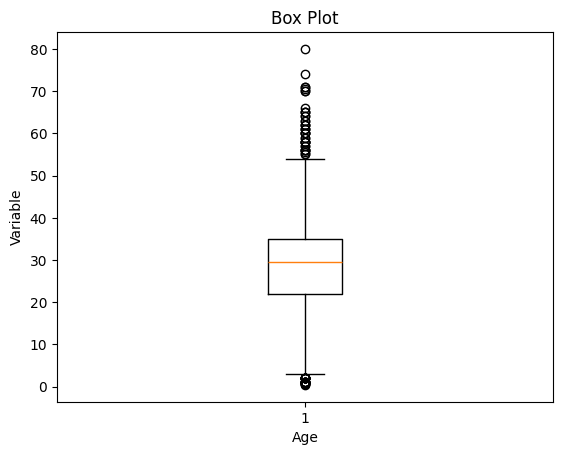

In [124]:
import matplotlib.pyplot as plt

plt.boxplot(df1['Age'])
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

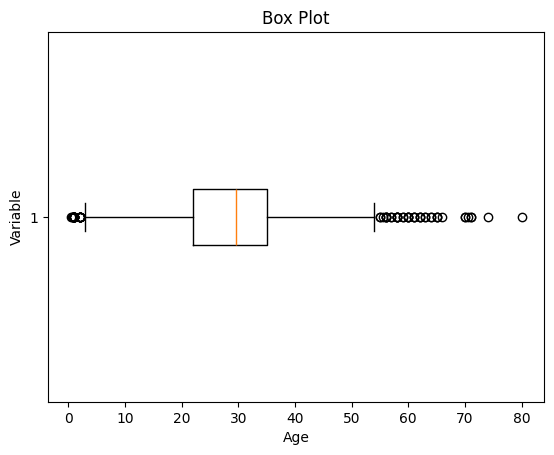

In [125]:
import matplotlib.pyplot as plt

plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

# This code uses a box plot to visualize the distribution of the Age column and detect outliers. 
# The plot shows key statistics like the median, quartiles (Q1 & Q3), 
# and extreme values, where points outside the whiskers are considered potential outliers. 
# plt.show() then displays the chart so you can visually inspect unusual age values.

### Step 8: Calculate Outlier Boundaries and Remove Them

- Calculate mean and standard deviation (std) using df['Age'].mean() and df['Age'].std().

- Define bounds as mean ± 2 * std for outlier detection.

- Filter DataFrame rows within bounds using Boolean indexing.

In [126]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std    # (removes negative/unrealistic ages)
upper_bound = mean + 2 * std    # (removes very old passengers)

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

# This code identifies and removes outliers in the Age column using the mean ± 2 × standard deviation rule. 
# It first calculates the mean and standard deviation, then defines lower and upper bounds, 
# and finally filters the dataset to keep only values within that range. 

Here it is in a clean tabular format:

| Rule (Threshold) | Data Kept | Interpretation         |
| ---------------- | --------- | ---------------------- |
| Mean ± 1 std     | ~68%      | Too aggressive         |
| Mean ± 2 std     | ~95%      | Moderate (your choice) |
| Mean ± 3 std     | ~99.7%    | More lenient           |

In [127]:
# Check how many rows were removed
print(f"Rows before: {len(df1)}")
print(f"Rows after: {len(df2)}")
print(f"Rows removed: {len(df1) - len(df2)}")

Rows before: 889
Rows after: 821
Rows removed: 68


In [128]:
# The result (df2) is a cleaner dataset with extreme age values (outliers) removed.
df2

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,2,1,1,female,38.000000,1,0,71.2833,C
2,3,1,3,female,26.000000,0,0,7.9250,S
3,4,1,1,female,35.000000,1,0,53.1000,S
4,5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S
887,888,1,1,female,19.000000,0,0,30.0000,S
888,889,0,3,female,29.642093,1,2,23.4500,S
889,890,1,1,male,26.000000,0,0,30.0000,C


### Step 9: Impute Missing Data Again if Any

- fillna() applied again on filtered data to handle any remaining missing values.

In [129]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()
# This code fills any remaining missing values in the filtered dataset (df2) using the mean of the Age column, ensuring no null values remain. 
# The result is stored in df3, and df3.isnull().sum() is used to verify that all missing values have been handled.

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

### Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data

- mean = df3['Age'].mean(): Calculates the average (mean) value of the Age column in the DataFrame df3.

- std = df3['Age'].std(): Computes the standard deviation (spread or variability) of the Age column in df3.

- lower_bound = mean - 2 * std: Defines the lower limit for acceptable Age values, set as two standard deviations below the mean.

- upper_bound = mean + 2 * std: Defines the upper limit for acceptable Age values, set as two standard deviations above the mean.

- df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]: Creates a new DataFrame df4 by selecting only rows where the Age value falls between the lower and upper bounds, effectively removing outlier ages outside this range.

In [130]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

# This code recalculates the outlier boundaries for the Age column after cleaning and imputation, using the mean ± 2 × standard deviation rule. 
# It then filters the dataset again to remove any remaining extreme values, ensuring the data is more consistent and less influenced by outliers.

Lower Bound : 8.978989004171453
Upper Bound : 49.30395961288914


In [131]:
# The final cleaned dataset (df4) contains only age values within the acceptable range, improving the quality of data for modeling.
df4

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.000000,1,0,7.2500,S
1,2,1,1,female,38.000000,1,0,71.2833,C
2,3,1,3,female,26.000000,0,0,7.9250,S
3,4,1,1,female,35.000000,1,0,53.1000,S
4,5,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.000000,0,0,13.0000,S
887,888,1,1,female,19.000000,0,0,30.0000,S
888,889,0,3,female,29.642093,1,2,23.4500,S
889,890,1,1,male,26.000000,0,0,30.0000,C


### Step 11: Data validation and verification

Data validation and verification involve ensuring that the data is accurate and consistent by comparing it with external sources or expert knowledge. 

- For the machine learning prediction we separate independent and target features

- Here we will consider 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', and 'Embarked' as independent features.

- Survived as target variables because PassengerId will not affect the survival rate.

In [132]:
# This step prepares the dataset for machine learning by separating it into features (X) and the target variable (Y). 
# The selected columns (Pclass, Sex, Age, SibSp, Parch, Fare, Embarked) are used as independent variables because they can influence survival, 
# while Survived is the target the model will predict. 
# This structure is essential for training a model to learn the relationship between passenger characteristics and survival outcomes.

# X - Things we KNOW about each passenger
X = ['Pclass',    # ticket class (1st, 2nd, 3rd)
     'Sex',       # male or female
     'Age',       # how old they are
     'SibSp',     # siblings/spouses aboard
     'Parch',     # parents/children aboard
     'Fare',      # how much they paid
     'Embarked']  # port they boarded from

# Y - What we want the MODEL to PREDICT
Y = ['Survived']  # 0 = died, 1 = survived

X (what we feed in)  ──────────► [ ML Model ] ──────────► Y (what comes out)

| Role               | What it means                 |
| ------------------ | ----------------------------- |
| X (Input/Features) | The information we know       |
| Y (Target/Label)   | The answer we want to predict |


- The model learns the relationship between X and Y during training

- After training, you give it new X values (new passenger data)

- It predicts Y (did they survive or not?)

`Without separating X and Y, the model wouldn't know what to learn from and what to predict.`

Real-world analogy:

Imagine you're a doctor predicting if a patient will recover:

X = age, weight, blood pressure, symptoms (what you observe)

Y = recovered or not (what you're trying to predict)

**Why PassengerId is excluded:**

- PassengerId is just a row number (1, 2, 3...)

- It has NO real relationship with survival

- Including it would confuse the model

`It's like using a student's ID number to predict their exam score — the number itself means nothing.`

### Step 12: Data formatting

Data formatting involves converting the data into a standard format or structure that can be easily processed by the algorithms or models used for analysis. Here we will discuss commonly used data formatting techniques i.e. Scaling and Normalization.

1. Min-Max Scaling: Scaling involves transforming the values of features to a specific range. Min-Max scaling rescales the values to a specified range, typically between 0 and 1. It preserves the original distribution and ensures that the minimum value maps to 0 and the maximum value maps to 1.

In [133]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in X.columns if X[col].dtype != 'object']
x1 = X
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()

# This code applies Min-Max Scaling to normalize the numerical features in your dataset so they all fall within the range 0 to 1. 
# It first identifies numeric columns (num_col_), then uses MinMaxScaler to transform those columns while leaving categorical ones unchanged. 
# The result (x1) is a scaled dataset where features are on the same scale, which helps machine learning models perform better and converge faster.

AttributeError: 'list' object has no attribute 'columns'

**NOTE: What is SettingWithCopyWarning?**

`It occurs when Pandas cannot determine whether you're modifying a view or a copy of a DataFrame.`

`To avoid unpredictable behavior, use .copy() or .loc for explicit assignment.`

In [ ]:
# Feature Scaling Using Min-Max Normalization using .copy()

from sklearn.preprocessing import MinMaxScaler

# Create a proper copy
x1 = X.copy()

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Select only numerical columns
num_col_ = [col for col in x1.columns if x1[col].dtype != 'object']

# Apply scaling safely using .loc
x1.loc[:, num_col_] = scaler.fit_transform(x1[num_col_])

# Preview
x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S


2. Standardization (Z-score scaling): Standardization transforms the values to have a mean of 0 and a standard deviation of 1. It centers the data around the mean and scales it based on the standard deviation. Standardization makes the data more suitable for algorithms that assume a Gaussian distribution or require features to have zero mean and unit variance.

`Z = (X - μ) / σ`

Where,

- X = Data

- μ = Mean value of X

- σ = Standard deviation of X

### Data Cleaning Strategies

- Understand the data: Know the source, structure and domain of the data to identify potential quality issues and determine appropriate cleaning actions.

- Document the process: Keep records of decisions, methods, assumptions and rules applied during data cleaning.

- Prioritize critical issues: Focus first on major quality problems that could have a systemic impact on analysis or decision-making.

- Automate where possible: Use scripts or tools for repetitive cleaning tasks to improve efficiency and consistency.

- Collaborate with domain experts: Engage stakeholders or domain specialists to validate that the cleaned data meets business requirements.

- Monitor and maintain: Continuously track data quality and perform cleaning periodically to ensure long-term accuracy and reliability.

### Advantages

- Removing errors, inconsistencies, and irrelevant data helps the model learn better from the data.

- Ensures the data is accurate, consistent, and free of errors.

- Transforms data into a format that better represents underlying patterns and relationships.

- Improves data quality, making it more reliable and accurate.

- Helps identify and remove sensitive or confidential information, improving data security.

### Disadvantages

- It is time-consuming, especially for large and complex datasets.

- It can lead to loss of important information if not handled carefully.

- Requires significant time, effort, expertise, and sometimes specialized tools.

- Removing too much data can contribute to underfitting.